<a href="https://colab.research.google.com/github/s4tlaw/KTH_AH2179/blob/main/AH2179_ASM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/refs/heads/main/Exercise_4_Text_classification/Pakistani%20Traffic%20sentiment%20Analysis.csv'
df = pd.read_csv(url)
df.head(10)

,Text,Sentiment
0,Adayala road is clear,0
1,Traffic jam from parbat rd to nazim-ud-din rd ...,1
2,Mandra is clear,0
3,Fort street is clear,0
4,"Mashriq Hotel towards Fawara Chowk, City Sadda...",1
5,Traffic jam from gulberg expy to margalla ave,1
6,Korang Rd road is free,0
7,Road open from Cantt Station to Lucky star,0
8,Zagid baig is clear,0
9,Traffic open from jaffar khan openali rd to se...,0


{'C': 1, 'kernel': 'rbf'}
The accuracy of the model is: 0.9620853080568721


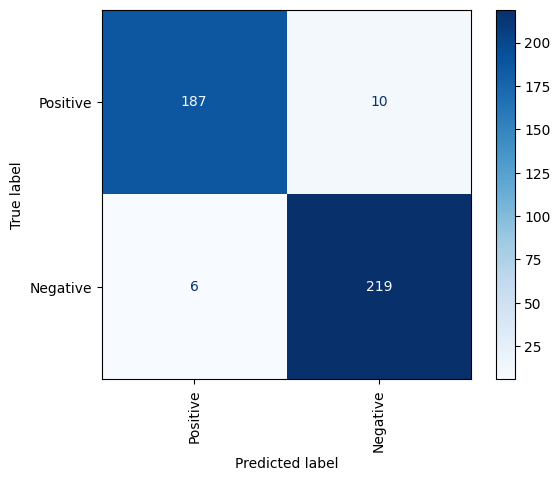

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
import os
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


#-*-*-*-*-*-*chose different vectorization-*-*-*-*-*-*

#(1) CountVectorizer
# vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words='english',min_df=20)

#(2) #HashingVectorizer
# vectorizer = HashingVectorizer(ngram_range=(1, 2), n_features=200)

#(3)TfidfVectorizer
vectorizer = TfidfVectorizer(
    min_df=20,
    norm='l2',
    smooth_idf=True,
    use_idf=True,
    ngram_range=(1, 1),
    stop_words='english'
    )

#-*-*-*-*-*-*chose different vectorization-*-*-*-*-*-*

# split into train/test set
x = df['Text']
y = df['Sentiment']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# apply the vectorizers
x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

# here you can try use the grid search to find the best model parameter(a example is in SVM model)
#-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
#(1)LR
# model = LogisticRegression(max_iter=1000, random_state=0)
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
# }

#(2)KNN
# model=KNeighborsClassifier()
# param_grid = {
#     'n_neighbors': [3, 5, 7, 9],
#     'weights': ['uniform', 'distance']
# }

#(3)RF
# model = RandomForestClassifier(random_state=0)
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

#(4)XGBoost
# model =  XGBClassifier()
# param_grid = {
#     'learning_rate': [0.01, 0.1, 0.2],
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 4, 5]
# }


#(5)SVM
model= SVC(probability=True)

# this is an example to use the grid search to find the best parameter for SVM model
# param_grid specifies the hyperparameter grid to search over： kernel types
# ('linear', 'rbf', 'poly') and regularization strength C values（0.1, 1, 10）.
param_grid = {'kernel': ['linear', 'rbf', 'poly'],'C': [0.1, 1, 10]}

#`grid_search` performs a grid search with 5-fold cross-validation and evaluates models based on accuracy.
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

#`fit` method fits the model to the training data, systematically trying out all
# parameter combinations.
grid_search.fit(x_train_vectorized, y_train)

#`best_params` and `best_score` store the best hyperparameters and their
# corresponding accuracy score.
best_params = grid_search.best_params_
print(best_params)
best_score = grid_search.best_score_

#The `model` is updated with the best estimator found during the grid search,
# which can be used for further analysis.
model = grid_search.best_estimator_

#(6)Naïve Bayes models
# model=BernoulliNB()
# param_grid = {'alpha': [0.1, 0.5, 1],'force_alpha': [True,False]}

#-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

cmd.from_estimator(
    model,
    x_test_vectorized,
    y_test,
    display_labels=['Positive','Negative'],
    cmap='Blues',
    xticks_rotation='vertical'
    )

#calculate accuracy
print('The accuracy of the model is: '+str(accuracy_score(y_test,model.predict(x_test_vectorized))))

CountVectorizer + LogisticRegression: acc=0.9479, best_params={'C': 10}
CountVectorizer + KNN: acc=0.9502, best_params={'n_neighbors': 9, 'weights': 'distance'}
CountVectorizer + RandomForest: acc=0.9716, best_params={'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
CountVectorizer + XGBoost: acc=0.9597, best_params={'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
CountVectorizer + SVM: acc=0.9597, best_params={'C': 1, 'kernel': 'rbf'}
CountVectorizer + NaiveBayes: acc=0.9502, best_params={'alpha': 0.5, 'force_alpha': True}
HashingVectorizer + LogisticRegression: acc=0.9502, best_params={'C': 10}
HashingVectorizer + KNN: acc=0.9431, best_params={'n_neighbors': 9, 'weights': 'distance'}
HashingVectorizer + RandomForest: acc=0.9763, best_params={'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
HashingVectorizer + XGBoost: acc=0.9645, best_params={'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 

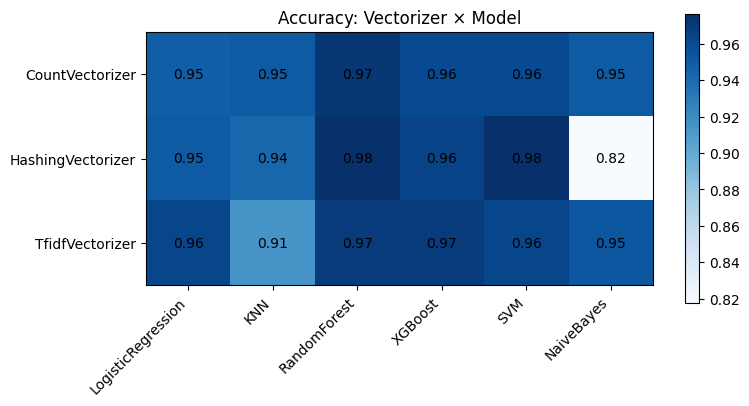

In [7]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# ---------- 1. Split data ----------
x = df['Text']
y = df['Sentiment']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# ---------- 2. Define the 3 vectorizers ----------
vectorizers = {
    'CountVectorizer': CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=20),
    'HashingVectorizer': HashingVectorizer(ngram_range=(1, 2), n_features=200),
    'TfidfVectorizer': TfidfVectorizer(
        min_df=20, norm='l2', smooth_idf=True, use_idf=True,
        ngram_range=(1, 1), stop_words='english'
    )
}

# ---------- 3. Define the 6 models + their grids ----------
models_grid = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=0),
                            {'C': [0.001, 0.01, 0.1, 1, 10, 100]}),
    'KNN': (KNeighborsClassifier(),
            {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}),
    'RandomForest': (RandomForestClassifier(random_state=0),
                      {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20, 30],
                       'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}),
    'XGBoost': (XGBClassifier(eval_metric='logloss'),
                {'learning_rate': [0.01, 0.1, 0.2], 'n_estimators': [100, 200, 300],
                 'max_depth': [3, 4, 5]}),
    'SVM': (SVC(probability=True),
            {'kernel': ['linear', 'rbf', 'poly'], 'C': [0.1, 1, 10]}),
    'NaiveBayes': (BernoulliNB(),
                   {'alpha': [0.1, 0.5, 1], 'force_alpha': [True, False]}),
}

# ---------- 4. Loop through all vectorizer/model combos ----------
results = pd.DataFrame(index=list(vectorizers.keys()),
                        columns=list(models_grid.keys()), dtype=float)
best_params_log = {}   # optional: store best hyperparams per combo

for vname, vec in vectorizers.items():
    x_train_v = vec.fit_transform(x_train)
    x_test_v = vec.transform(x_test)

    for mname, (model, param_grid) in models_grid.items():
        gs = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
        gs.fit(x_train_v, y_train)
        best_model = gs.best_estimator_

        acc = accuracy_score(y_test, best_model.predict(x_test_v))
        results.loc[vname, mname] = acc
        best_params_log[(vname, mname)] = gs.best_params_

        print(f"{vname} + {mname}: acc={acc:.4f}, best_params={gs.best_params_}")

# ---------- 5. Final matrix ----------
print(results)

# ---------- 6. Optional heatmap visualization ----------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(results.values.astype(float), cmap='Blues')
ax.set_xticks(range(len(results.columns))); ax.set_xticklabels(results.columns, rotation=45, ha='right')
ax.set_yticks(range(len(results.index))); ax.set_yticklabels(results.index)
for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        ax.text(j, i, f"{results.iloc[i, j]:.2f}", ha='center', va='center')
plt.colorbar(im)
plt.title("Accuracy: Vectorizer × Model")
plt.tight_layout()
plt.show()